# Visualize the Node2Vec Embeddings

By visualizing the node2vec embeddings with a TSNE or a UMAP, we might be able estimate how many clusters we really think there are in the PPI network. This notebook can also be used to visualize the distribution of clusters as well, which we will need to do for comparing against Kaggle results. 

In [7]:
import pickle
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from decimal import Decimal
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## Load in Node2Vec Embeddings and Cluster Results Filtered by Different Weights

### Weight > 0.5

In [3]:
with open("node2vec_embeddings_0.5.pkl", "rb") as handle:
    embeddings_5 = pickle.load(handle)

clusters_5 = pd.read_csv("protein_clusters_0.5.csv")
clusters_5.head()

,id,xxx,prediction
0,0,MAL944N3R,cluster1
1,1,2P070I351,cluster1
2,2,LPAXLZS35,cluster6
3,3,2IUMVXWR8,cluster6
4,4,IYMKO9LF4,cluster2


In [4]:
len(list(set(list(clusters_5["xxx"]))))

5147

### Weight > 0.6

In [19]:
with open("node2vec_embeddings_0.6.pkl", "rb") as handle:
    embeddings_6 = pickle.load(handle)

clusters_6 = pd.read_csv("protein_clusters_0.6.csv")
clusters_6.head()

,id,xxx,prediction
0,0,MAL944N3R,cluster14
1,1,2P070I351,cluster14
2,2,LPAXLZS35,cluster4
3,3,2IUMVXWR8,cluster4
4,4,IYMKO9LF4,cluster18


### Weight > 0.7

In [8]:
with open("node2vec_embeddings.pkl", "rb") as handle:
    embeddings_7 = pickle.load(handle)

clusters_7 = pd.read_csv("protein_clusters.csv")
clusters_7.head()

,id,xxx,prediction
0,0,MAL944N3R,cluster18
1,1,2P070I351,cluster18
2,2,LPAXLZS35,cluster1
3,3,2IUMVXWR8,cluster1
4,4,IYMKO9LF4,cluster2


### Weight > 0.8

In [9]:
with open("node2vec_embeddings_0.8.pkl", "rb") as handle:
    embeddings_8 = pickle.load(handle)

clusters_8 = pd.read_csv("protein_clusters_0.8.csv")
clusters_8.head()

,id,xxx,prediction
0,0,MAL944N3R,cluster15
1,1,2P070I351,cluster15
2,2,LPAXLZS35,cluster44
3,3,2IUMVXWR8,cluster44
4,4,IYMKO9LF4,cluster9


### Weight > 0.9

In [15]:
with open("node2vec_embeddings_0.9.pkl", "rb") as handle:
    embeddings_9 = pickle.load(handle)

clusters_9 = pd.read_csv("protein_clusters_0.9.csv")
clusters_9.head()

,id,xxx,prediction
0,0,MAL944N3R,cluster1
1,1,2P070I351,cluster1
2,2,LPAXLZS35,cluster1
3,3,2IUMVXWR8,cluster8
4,4,IYMKO9LF4,cluster8


## Visualize the Node2Vec Embedding Space

### Weight > 0.7

/cellar/users/zwallace/miniconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/tmp/ipykernel_281281/3400466826.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", num_labels)


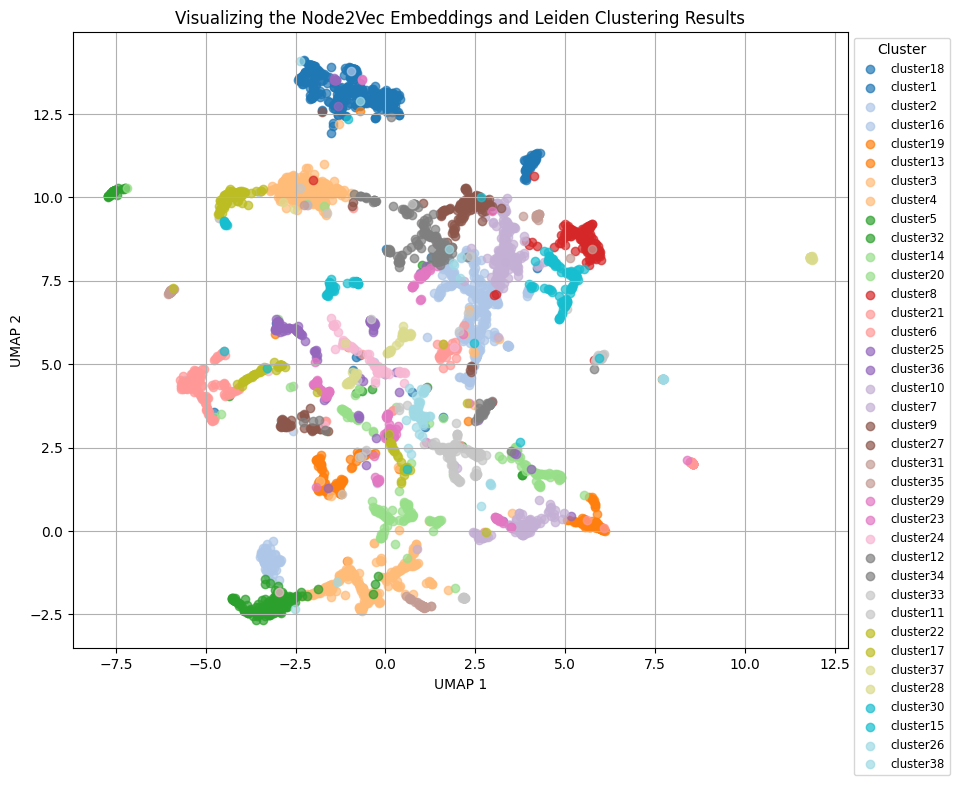

In [10]:
# Get dict of proteins to cluster
cluster_name_indices = {}
for ind in clusters_7.index:
    protein_id = int(clusters_7["id"][ind])
    cluster = str(clusters_7["prediction"][ind])
    if cluster_name_indices.get(cluster):
        cluster_name_indices[cluster].append(protein_id)
    else:
        cluster_name_indices[cluster] = [protein_id]

# Create tsne plot colored by clusters
matrix = np.asarray(embeddings_7.values)
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric='cosine')
umap_result = reducer.fit_transform(embeddings)

num_labels = len(cluster_name_indices.keys())
cmap = cm.get_cmap("tab20", num_labels)
colors = [cmap(i) for i in range(num_labels)]

plt.figure(figsize=(10, 8))

for i, (label, indices) in enumerate(cluster_name_indices.items()):
    plt.scatter(umap_result[indices, 0], umap_result[indices, 1], label=label, color=colors[i % len(colors)], alpha=0.7)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Visualizing the Node2Vec Embeddings and Leiden Clustering Results", fontsize=12)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize="small", title="Cluster")
plt.grid(True)
plt.show()

In [13]:
len(list(set(list(clusters_7["prediction"]))))

38

### Weight > 0.8

/cellar/users/zwallace/miniconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/tmp/ipykernel_281281/2129934700.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", num_labels)


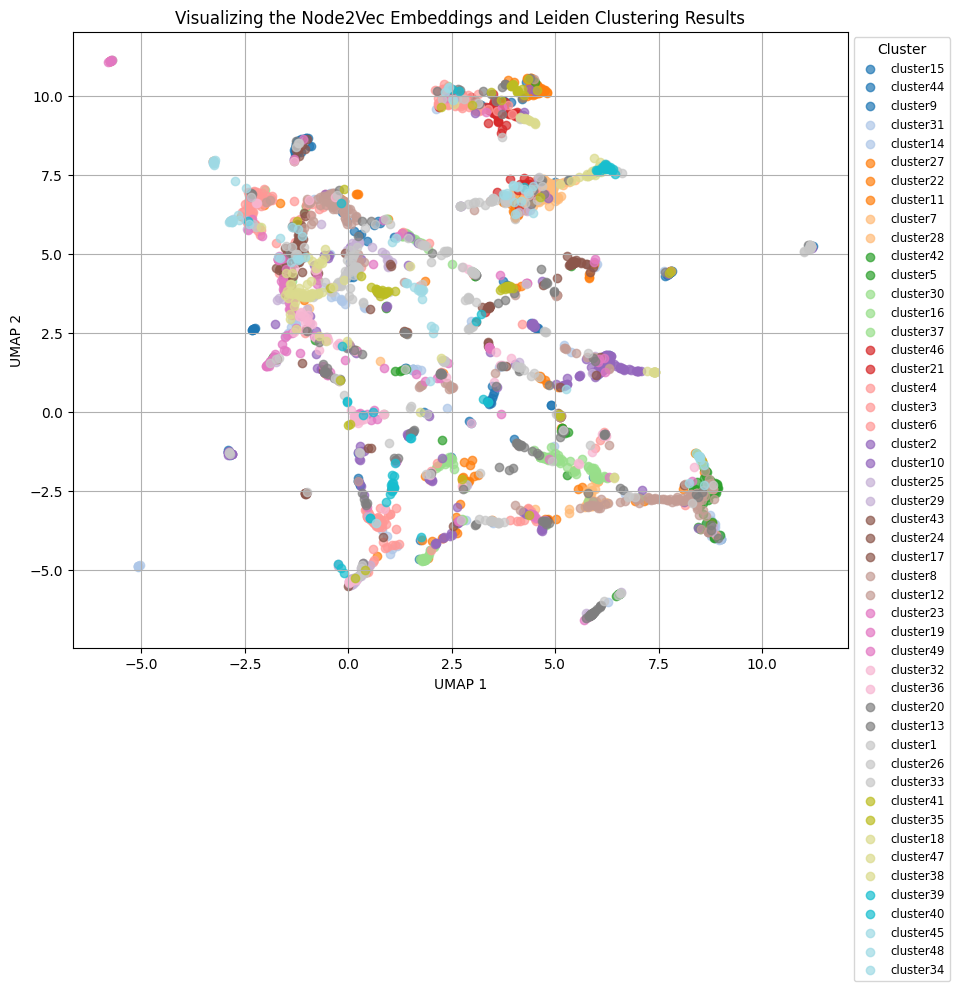

In [11]:
# Get dict of proteins to cluster
cluster_name_indices = {}
for ind in clusters_8.index:
    protein_id = int(clusters_8["id"][ind])
    cluster = str(clusters_8["prediction"][ind])
    if cluster_name_indices.get(cluster):
        cluster_name_indices[cluster].append(protein_id)
    else:
        cluster_name_indices[cluster] = [protein_id]

# Create tsne plot colored by clusters
matrix = np.asarray(embeddings_8.values)
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric='cosine')
umap_result = reducer.fit_transform(embeddings)

num_labels = len(cluster_name_indices.keys())
cmap = cm.get_cmap("tab20", num_labels)
colors = [cmap(i) for i in range(num_labels)]

plt.figure(figsize=(10, 8))

for i, (label, indices) in enumerate(cluster_name_indices.items()):
    plt.scatter(umap_result[indices, 0], umap_result[indices, 1], label=label, color=colors[i % len(colors)], alpha=0.7)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Visualizing the Node2Vec Embeddings and Leiden Clustering Results", fontsize=12)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize="small", title="Cluster")
plt.grid(True)
plt.show()

In [14]:
len(list(set(list(clusters_8["prediction"]))))

49

### Weight > 0.9

/cellar/users/zwallace/miniconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/tmp/ipykernel_281281/3336790716.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", num_labels)


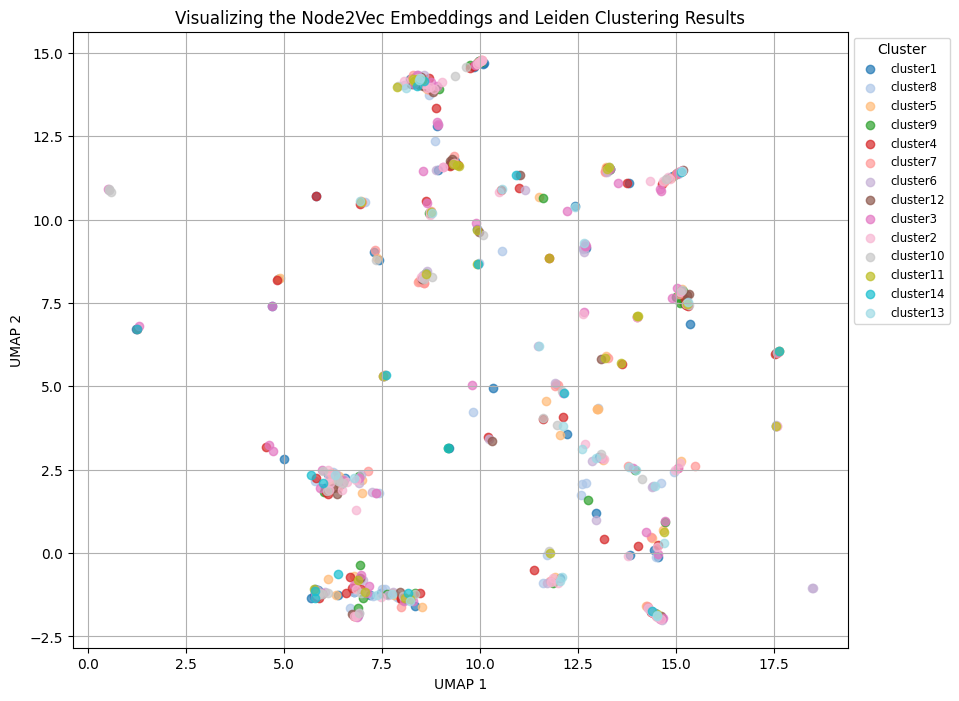

In [16]:
# Get dict of proteins to cluster
cluster_name_indices = {}
for ind in clusters_9.index:
    protein_id = int(clusters_9["id"][ind])
    cluster = str(clusters_9["prediction"][ind])
    if cluster_name_indices.get(cluster):
        cluster_name_indices[cluster].append(protein_id)
    else:
        cluster_name_indices[cluster] = [protein_id]

# Create tsne plot colored by clusters
matrix = np.asarray(embeddings_9.values)
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric='cosine')
umap_result = reducer.fit_transform(embeddings)

num_labels = len(cluster_name_indices.keys())
cmap = cm.get_cmap("tab20", num_labels)
colors = [cmap(i) for i in range(num_labels)]

plt.figure(figsize=(10, 8))

for i, (label, indices) in enumerate(cluster_name_indices.items()):
    plt.scatter(umap_result[indices, 0], umap_result[indices, 1], label=label, color=colors[i % len(colors)], alpha=0.7)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Visualizing the Node2Vec Embeddings and Leiden Clustering Results", fontsize=12)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize="small", title="Cluster")
plt.grid(True)
plt.show()

In [17]:
len(list(set(list(clusters_9["prediction"]))))

14

### Weight > 0.5

In [20]:
len(list(set(list(clusters_5["prediction"]))))

10

### Weight > 0.6

In [21]:
len(list(set(list(clusters_6["prediction"]))))

19

## Histogram of clusters

In [8]:
from collections import Counter

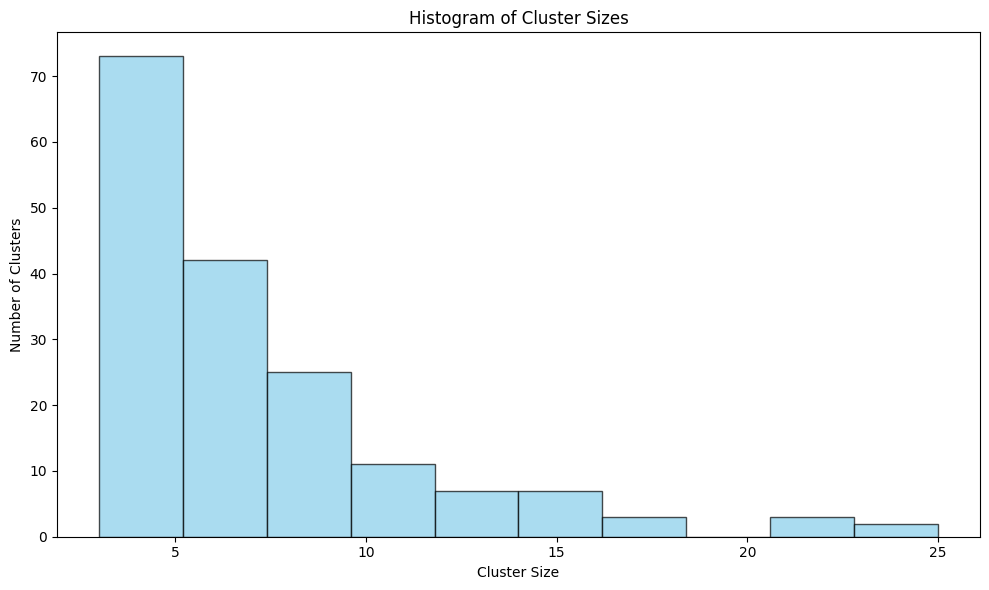

In [14]:
clusters = pd.read_csv("protein_hidef_clusters_nn10.csv")
clusters = list(clusters["prediction"])

string_counts = Counter(clusters)
frequencies = list(string_counts.values())
    
plt.figure(figsize=(10, 6))
plt.hist(frequencies, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Cluster Size')
plt.ylabel('Number of Clusters')
plt.title('Histogram of Cluster Sizes')
plt.tight_layout()
    
plt.show()